# 학습된 모델을 활용한 추론

**작성**: 연구자 2

**연구 계획**
- DockerHub 를 통해 연구자 1이 만든 이미지를 pull 받습니다.
- 이미지의 위치 : `yopkigom/student-perf-train:1.0`
- 이 노트북은 docker-compose로 띄운 Jupyter 컨테이너 안에서 실행됩니다.
- 추론 결과는 `shared/result.csv`로 저장합니다.

**주요 파일 구성** 
| 파일 | 확보 경로 |
|---|---|
| `shared/model.pkl` | `docker compose`의 trainer 서비스가 학습 후 **공유 볼륨**에 저장 |
| `shared/mission15_test.csv` | 이미지로 만든 컨테이너에서 **`docker cp`** 로 추출 |
| `requirements.txt` | 동일하게 `docker cp`로 추출 →<br>이 Jupyter 이미지 빌드에 사용 (**패키지 버전 통일**) |

## 0. 패키지 임포트 및 버전 확인

In [1]:
import platform

import joblib
import numpy as np
import pandas as pd
import sklearn

# Must match researcher 1's environment (same base image + requirements.txt)
print(f"python       : {platform.python_version()}")
print(f"numpy        : {np.__version__}")
print(f"pandas       : {pd.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"joblib       : {joblib.__version__}")

python       : 3.11.15
numpy        : 1.26.4
pandas       : 2.2.2
scikit-learn : 1.5.1
joblib       : 1.4.2


## 1. 모델 로드 및 전역 참조 값 설정

trainer 컨테이너가 공유 볼륨(`shared/`)에 저장한 학습 완료 파이프라인을 로드합니다.  
파이프라인에 표준화(전처리, StandardScaler)가 포함되어 있어  
원본 스케일 입력을 그대로 사용할 수 있습니다.

In [2]:
MODEL_PATH = "shared/model.pkl"
TEST_CSV_PATH = "shared/mission15_test.csv"
RESULT_CSV_PATH = "shared/result.csv"
CATEGORICAL_COLUMN = "Extracurricular Activities"

try:
    model = joblib.load(MODEL_PATH)
except FileNotFoundError:
    raise SystemExit(
        f"Model not found: {MODEL_PATH} — run the trainer service first "
        "(docker compose up trainer)"
    )

model

Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor', LinearRegression())])

## 2. 테스트 데이터 로드

In [3]:
try:
    test_df = pd.read_csv(TEST_CSV_PATH)
except FileNotFoundError:
    raise SystemExit(
        f"Test data not found: {TEST_CSV_PATH} — extract it from the "
        "trainer image with 'docker cp' first"
    )

print(f"shape: {test_df.shape}")
print(f"missing values: {test_df.isna().sum().sum()}")
test_df.head()

shape: (3000, 5)
missing values: 0


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,Yes,9,1
1,8,51,Yes,7,2
2,8,91,No,4,5
3,5,79,No,7,8
4,2,72,No,4,3


## 3. 전처리 및 추론

연구자 1의 학습 전처리와 **동일한 규칙**(Yes/No → 1/0)을 적용합니다.  
아까 언급했듯이, 스케일링은 파이프라인 내부에서 자동 처리됩니다.

In [4]:
def preprocess_features(df: pd.DataFrame) -> pd.DataFrame:
    """Mirror researcher 1's preprocessing (Yes/No -> 1/0)."""
    out = df.copy()
    out[CATEGORICAL_COLUMN] = out[CATEGORICAL_COLUMN].map({"Yes": 1, "No": 0})
    if out[CATEGORICAL_COLUMN].isna().any():
        raise ValueError(f"Unexpected value in '{CATEGORICAL_COLUMN}'")
    return out


X_test = preprocess_features(test_df)
predictions = model.predict(X_test)
print(f"predictions: {predictions.shape}")
pd.Series(predictions).describe().round(2)

predictions: (3000,)


count    3000.00
mean       55.54
std        19.25
min        13.01
25%        40.33
50%        55.49
75%        70.94
max        98.46
dtype: float64

### 예측값 분포 확인

학습 데이터의 목표변수 범위(10~100)와 유사한 분포인지 눈으로 검증합니다.

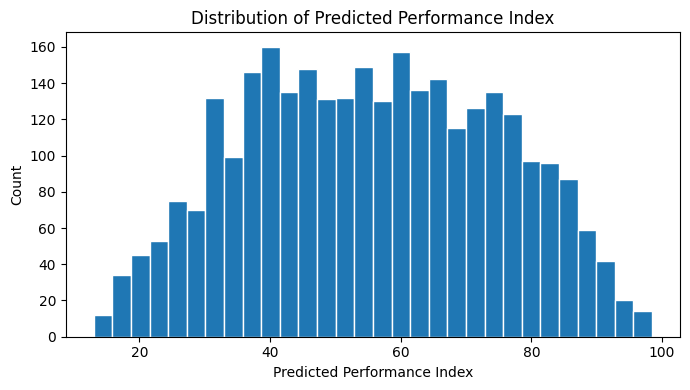

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(predictions, bins=30, edgecolor="white")
ax.set_title("Distribution of Predicted Performance Index")
ax.set_xlabel("Predicted Performance Index")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

30 구간과 70 구간에서의 분포가 다르게 관찰된 것 외에는  
나머지 구간에서는 유사한 분포를 보입니다.

## 4. 결과 저장

원본 테스트 데이터에 예측 컬럼을 붙여 `shared/result.csv`로 저장합니다.  
공유 볼륨에 저장되므로 호스트에서도 바로 확인할 수 있습니다.

In [6]:
import os

result_df = test_df.copy()
result_df["Predicted Performance Index"] = np.round(predictions, 2)

result_df.to_csv(RESULT_CSV_PATH, index=False)
print(f"saved: {RESULT_CSV_PATH} "
      f"({len(result_df)} rows, {os.path.getsize(RESULT_CSV_PATH)} bytes)")
result_df.head()

saved: shared/result.csv (3000 rows, 55346 bytes)


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Predicted Performance Index
0,7,99,Yes,9,1,91.85
1,8,51,Yes,7,2,45.07
2,8,91,No,4,5,84.33
3,5,79,No,7,8,65.58
4,2,72,No,4,3,47.43


## 5. 결론

- 연구자 1의 Docker Hub 이미지만으로  
    모델(`model.pkl`)과 데이터(`test.csv`)를 확보해 추론을 진행하였습니다.
- 두 컨테이너가 동일 베이스 이미지 + 동일 `requirements.txt`를 사용하므로  
    버전 불일치 위험이 없었습니다.
- 산출물: `shared/result.csv` (3,000행, 예측 컬럼 포함)